# EcoShield AI — Heavy LightGBM Modeli

Bu notebook, **IEEE-CIS Fraud Detection** veri seti üzerinde ağır LightGBM model adayını baştan sona hazırlamak için oluşturulmuştur.

Notebook şu işlemleri içerir:

1. Google Drive bağlantısı ve proje yollarının hazırlanması
2. `train_transaction.csv` ve `train_identity.csv` dosyalarının okunması
3. Tabloların `TransactionID` üzerinden birleştirilmesi
4. Train / validation / test ayrımı
5. Train verisine göre kolon temizliği ve kategorik veri hazırlığı
6. Class imbalance için `scale_pos_weight` hesaplanması
7. Heavy LightGBM modelinin early stopping ile eğitilmesi
8. Validation setinde threshold tuning
9. Test metrikleri, confusion matrix, PR ve ROC eğrileri
10. Feature importance analizi
11. Model, metadata, metrik, tahmin ve görsellerin kaydedilmesi

> Bu dosya çalıştırılmamış bir notebook şablonudur. İlk çalıştırmadan önce yalnızca **Yapılandırma** hücresindeki Drive yolunu kontrol etmeniz yeterlidir.

## Beklenen klasör yapısı

```text
EcoShieldAI/
├── data/
│   └── raw/
│       ├── train_transaction.csv
│       └── train_identity.csv
├── models/
│   └── heavy/
└── outputs/
    ├── figures/
    ├── metrics/
    └── predictions/
```

CSV dosyaları farklı bir alt klasördeyse notebook proje klasörü içinde isimleriyle aramayı dener.

In [ ]:
# ============================================================
# 1) YAPILANDIRMA
# ============================================================

# Drive içindeki proje klasörünüz.
# Gerekirse yalnızca bu satırı değiştirin.
PROJECT_ROOT = "/content/drive/MyDrive/EcoShieldAI"

# Tam eğitim için False bırakın.
# Önce kod akışını hızlı kontrol etmek için True yapılabilir.
QUICK_MODE = False

# QUICK_MODE=True olduğunda okunacak transaction satırı.
QUICK_ROWS = 150_000

# CSV dosyaları parça parça okunurken kullanılacak satır sayısı.
CSV_CHUNK_SIZE = 100_000

# Train verisinde bu orandan daha fazla eksiği olan kolonlar kaldırılır.
HIGH_MISSING_THRESHOLD = 0.98

# Veri bölme oranları.
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

# Tekrarlanabilirlik.
RANDOM_STATE = 42

# Validation üzerinde threshold seçerken hedeflenen minimum recall.
MIN_RECALL_TARGET = 0.90

# Önce GPU denenmesini istiyorsanız True yapın.
# Standart Colab LightGBM kurulumu GPU desteği vermeyebilir;
# bu durumda kod otomatik olarak CPU'ya geçer.
TRY_GPU_FIRST = False

# Heavy LightGBM başlangıç parametreleri.
LGBM_N_ESTIMATORS = 2_000
LGBM_LEARNING_RATE = 0.03
LGBM_NUM_LEAVES = 63
LGBM_MIN_CHILD_SAMPLES = 50
EARLY_STOPPING_ROUNDS = 100

print("Yapılandırma hazır.")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("QUICK_MODE:", QUICK_MODE)
print("TRY_GPU_FIRST:", TRY_GPU_FIRST)

## Gerekli paketler

Eksik paketler varsa otomatik kurulur. Kurulumdan sonra import hatası oluşursa Colab oturumunu bir kez yeniden başlatıp **Run all** çalıştırabilirsiniz.

In [ ]:
# ============================================================
# 2) GEREKLİ PAKETLERİ KONTROL ET / KUR
# ============================================================

import importlib.util
import subprocess
import sys

required_packages = {
    "lightgbm": "lightgbm",
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
    "psutil": "psutil",
    "joblib": "joblib",
}

missing_packages = [
    pip_name
    for import_name, pip_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Eksik paketler kuruluyor:", missing_packages)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )
    print("Kurulum tamamlandı.")
else:
    print("Gerekli paketlerin tamamı kurulu.")

In [ ]:
# ============================================================
# 3) IMPORTLAR
# ============================================================

import gc
import json
import os
import platform
import time
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

print("Python:", sys.version.split()[0])
print("İşletim sistemi:", platform.platform())
print("Pandas:", pd.__version__)
print("LightGBM:", lgb.__version__)
print("Toplam RAM:", round(psutil.virtual_memory().total / (1024 ** 3), 2), "GB")

## Google Drive bağlantısı

Colab dışında çalıştırıldığında bu hücre Drive bağlantısını atlar.

In [ ]:
# ============================================================
# 4) GOOGLE DRIVE BAĞLANTISI
# ============================================================

try:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    else:
        print("Google Drive zaten bağlı.")
except ImportError:
    print("Google Colab dışında çalışılıyor; Drive mount adımı atlandı.")

In [ ]:
# ============================================================
# 5) PROJE VE ÇIKTI KLASÖRLERİ
# ============================================================

PROJECT_ROOT = Path(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

MODEL_DIR = PROJECT_ROOT / "models" / "heavy"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
PREDICTIONS_DIR = PROJECT_ROOT / "outputs" / "predictions"

for directory in [
    MODEL_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proje kökü:", PROJECT_ROOT)
print("Ham veri klasörü:", RAW_DIR)
print("Model klasörü:", MODEL_DIR)
print("Metrik klasörü:", METRICS_DIR)
print("Görsel klasörü:", FIGURES_DIR)
print("Tahmin klasörü:", PREDICTIONS_DIR)

## Yardımcı fonksiyonlar

Bu fonksiyonlar:

- RAM kullanımını gösterir,
- CSV dosyalarını parça parça okur,
- sayısal veri tiplerini küçültür,
- proje içinde dosya arar,
- her adımın çalışma süresini raporlar.

In [ ]:
# ============================================================
# 6) YARDIMCI FONKSİYONLAR
# ============================================================

def memory_usage_gb() -> float:
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 3)


def print_memory(note: str = "") -> None:
    prefix = f"[{note}] " if note else ""
    print(f"{prefix}RAM kullanımı: {memory_usage_gb():.2f} GB")


def downcast_numeric_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    float_cols = frame.select_dtypes(include=["float64"]).columns
    int_cols = frame.select_dtypes(include=["int64"]).columns

    for col in float_cols:
        frame[col] = pd.to_numeric(frame[col], downcast="float")

    for col in int_cols:
        frame[col] = pd.to_numeric(frame[col], downcast="integer")

    return frame


def read_csv_with_progress(
    path: Path,
    chunksize: int = 100_000,
    nrows: int | None = None,
) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Dosya bulunamadı: {path}")

    started = time.perf_counter()
    chunks = []

    reader = pd.read_csv(
        path,
        chunksize=chunksize,
        nrows=nrows,
        low_memory=False,
    )

    progress = tqdm(
        desc=f"{path.name} okunuyor",
        unit=" satır",
    )

    for chunk in reader:
        chunk = downcast_numeric_dtypes(chunk)
        chunks.append(chunk)
        progress.update(len(chunk))
        progress.set_postfix(
            ram=f"{memory_usage_gb():.2f} GB",
            refresh=False,
        )

    progress.close()

    result = pd.concat(chunks, ignore_index=True)
    elapsed = time.perf_counter() - started

    print(
        f"{path.name}: {len(result):,} satır, "
        f"{result.shape[1]} kolon, süre={elapsed:.1f} sn"
    )
    print_memory(path.name)

    del chunks
    gc.collect()

    return result


def locate_file(filename: str) -> Path:
    direct_candidates = [
        RAW_DIR / filename,
        DATA_DIR / filename,
        PROJECT_ROOT / filename,
        Path("/content") / filename,
    ]

    for candidate in direct_candidates:
        if candidate.exists():
            return candidate

    search_roots = [
        RAW_DIR,
        DATA_DIR,
        PROJECT_ROOT,
        Path("/content"),
    ]

    found = []

    for root in search_roots:
        if root.exists():
            found.extend(root.rglob(filename))

    found = list(dict.fromkeys(found))

    if not found:
        raise FileNotFoundError(
            f"{filename} bulunamadı. Dosyayı Drive içindeki "
            f"{RAW_DIR} klasörüne koyun veya PROJECT_ROOT yolunu değiştirin."
        )

    if len(found) > 1:
        print(f"{filename} için birden fazla dosya bulundu:")
        for path in found:
            print(" -", path)
        print("İlk dosya kullanılacak:", found[0])

    return found[0]


class StepTimer:
    def __init__(self, name: str):
        self.name = name
        self.started = None

    def __enter__(self):
        self.started = time.perf_counter()
        print(f"\n{'=' * 70}")
        print(f"BAŞLADI: {self.name}")
        print(f"{'=' * 70}")
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        elapsed = time.perf_counter() - self.started

        if exc_type is None:
            print(f"TAMAMLANDI: {self.name} — {elapsed:.1f} sn")
            print_memory(self.name)
        else:
            print(f"HATA: {self.name} — {exc_val}")

        return False

In [ ]:
# ============================================================
# 7) IEEE-CIS DOSYALARINI BUL
# ============================================================

TRANSACTION_PATH = locate_file("train_transaction.csv")
IDENTITY_PATH = locate_file("train_identity.csv")

print("Transaction dosyası:", TRANSACTION_PATH)
print("Identity dosyası:", IDENTITY_PATH)

## Verilerin okunması ve birleştirilmesi

`QUICK_MODE=True` yalnızca kod akışını test etmek içindir. Final sonuçlar tam veri üzerinden alınmalıdır.

In [15]:
# ============================================================
# 8) VERİLERİ OKU
# ============================================================

transaction_nrows = QUICK_ROWS if QUICK_MODE else None

with StepTimer("Transaction verisini okuma"):
    transaction = read_csv_with_progress(
        TRANSACTION_PATH,
        chunksize=CSV_CHUNK_SIZE,
        nrows=transaction_nrows,
    )

with StepTimer("Identity verisini okuma"):
    identity = read_csv_with_progress(
        IDENTITY_PATH,
        chunksize=CSV_CHUNK_SIZE,
        nrows=None,
    )

if QUICK_MODE:
    valid_ids = set(transaction["TransactionID"].tolist())
    identity = identity[
        identity["TransactionID"].isin(valid_ids)
    ].reset_index(drop=True)

print("\nTransaction shape:", transaction.shape)
print("Identity shape:", identity.shape)


BAŞLADI: Transaction verisini okuma


train_transaction.csv okunuyor: 0 satır [00:00, ? satır/s]

train_transaction.csv: 590,540 satır, 394 kolon, süre=69.5 sn
[train_transaction.csv] RAM kullanımı: 2.07 GB
TAMAMLANDI: Transaction verisini okuma — 69.8 sn
[Transaction verisini okuma] RAM kullanımı: 2.06 GB

BAŞLADI: Identity verisini okuma


train_identity.csv okunuyor: 0 satır [00:00, ? satır/s]

train_identity.csv: 144,233 satır, 41 kolon, süre=1.5 sn
[train_identity.csv] RAM kullanımı: 2.06 GB
TAMAMLANDI: Identity verisini okuma — 1.6 sn
[Identity verisini okuma] RAM kullanımı: 2.06 GB

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [ ]:
# ============================================================
# 9) TRANSACTION VE IDENTITY TABLOLARINI BİRLEŞTİR
# ============================================================

with StepTimer("Transaction + Identity birleştirme"):
    df = transaction.merge(
        identity,
        on="TransactionID",
        how="left",
        validate="one_to_one",
    )

    del transaction, identity
    gc.collect()

print("Birleşik veri shape:", df.shape)
print("\nFraud dağılımı:")
print(df["isFraud"].value_counts(dropna=False))
print("\nFraud oranı:", f"{df['isFraud'].mean():.6f}")
print("Duplicate satır:", df.duplicated().sum())


BAŞLADI: Transaction + Identity birleştirme
TAMAMLANDI: Transaction + Identity birleştirme — 2.7 sn
[Transaction + Identity birleştirme] RAM kullanımı: 3.16 GB
Birleşik veri shape: (590540, 434)

Fraud dağılımı:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud oranı: 0.034990
Duplicate satır: 0


## Target ayrımı ve train / validation / test split

- `isFraud` target olarak ayrılır.
- `TransactionID` model girdisinden çıkarılır fakat tahmin çıktıları için saklanır.
- Split işlemi `stratify=y` ile yapılır.
- Kolon temizleme kararları yalnızca **train verisine** göre verilir.

In [ ]:
# ============================================================
# 10) TARGET, ID VE HAM FEATURE AYRIMI
# ============================================================

TARGET_COL = "isFraud"
ID_COL = "TransactionID"

if TARGET_COL not in df.columns:
    raise KeyError(f"Target kolonu bulunamadı: {TARGET_COL}")

if ID_COL not in df.columns:
    raise KeyError(f"ID kolonu bulunamadı: {ID_COL}")

ids = df[ID_COL].copy()
y = df[TARGET_COL].astype(np.int8).copy()
raw_features = df.drop(columns=[TARGET_COL, ID_COL])

del df
gc.collect()

print("Ham feature shape:", raw_features.shape)
print("Target shape:", y.shape)
print("Fraud oranı:", y.mean())

Ham feature shape: (590540, 432)
Target shape: (590540,)
Fraud oranı: 0.03499000914417313


In [ ]:
# ============================================================
# 11) STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

all_indices = np.arange(len(raw_features))

temp_size = VALIDATION_SIZE + TEST_SIZE
test_share_inside_temp = TEST_SIZE / temp_size

with StepTimer("Train / validation / test ayrımı"):
    train_idx, temp_idx = train_test_split(
        all_indices,
        test_size=temp_size,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=test_share_inside_temp,
        stratify=y.iloc[temp_idx],
        random_state=RANDOM_STATE,
    )

    X_train = raw_features.iloc[train_idx].reset_index(drop=True)
    X_val = raw_features.iloc[val_idx].reset_index(drop=True)
    X_test = raw_features.iloc[test_idx].reset_index(drop=True)

    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    id_train = ids.iloc[train_idx].reset_index(drop=True)
    id_val = ids.iloc[val_idx].reset_index(drop=True)
    id_test = ids.iloc[test_idx].reset_index(drop=True)

    del raw_features, ids
    gc.collect()

for name, X_part, y_part in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test),
]:
    print(
        f"{name}: X={X_part.shape}, y={y_part.shape}, "
        f"fraud oranı={y_part.mean():.6f}"
    )

np.savez_compressed(
    METRICS_DIR / "lightgbm_split_indices.npz",
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)


BAŞLADI: Train / validation / test ayrımı
TAMAMLANDI: Train / validation / test ayrımı — 4.8 sn
[Train / validation / test ayrımı] RAM kullanımı: 2.91 GB
Train: X=(413378, 432), y=(413378,), fraud oranı=0.034990
Validation: X=(88581, 432), y=(88581,), fraud oranı=0.034996
Test: X=(88581, 432), y=(88581,), fraud oranı=0.034985


## Train verisine göre feature hazırlığı

Aşağıdaki işlemler uygulanır:

- Train verisinde `%98` üzeri eksik olan kolonlar kaldırılır.
- Train verisinde sabit olan kolonlar kaldırılır.
- Bilinen kategorik IEEE-CIS kolonları ve object kolonları kategorik olarak işaretlenir.
- Kategorik seviyeler yalnızca train verisinden öğrenilir.
- Validation ve testte train sırasında görülmeyen kategoriler eksik kategori olarak değerlendirilir.
- Sayısal sonsuz değerler `NaN` yapılır.

In [ ]:
# ============================================================
# 12) TRAIN VERİSİNE GÖRE KOLON TEMİZLİĞİ
# ============================================================

with StepTimer("Kolon temizliği"):
    missing_ratio_train = X_train.isna().mean()

    high_missing_cols = missing_ratio_train[
        missing_ratio_train > HIGH_MISSING_THRESHOLD
    ].index.tolist()

    constant_cols = [
        col
        for col in X_train.columns
        if X_train[col].nunique(dropna=False) <= 1
    ]

    drop_cols = sorted(set(high_missing_cols + constant_cols))

    if drop_cols:
        X_train = X_train.drop(columns=drop_cols)
        X_val = X_val.drop(columns=drop_cols)
        X_test = X_test.drop(columns=drop_cols)

print("Kaldırılan yüksek missing kolon:", len(high_missing_cols))
print("Kaldırılan sabit kolon:", len(constant_cols))
print("Kalan feature sayısı:", X_train.shape[1])


BAŞLADI: Kolon temizliği
TAMAMLANDI: Kolon temizliği — 3.1 sn
[Kolon temizliği] RAM kullanımı: 2.14 GB
Kaldırılan yüksek missing kolon: 9
Kaldırılan sabit kolon: 0
Kalan feature sayısı: 423


In [ ]:
# ============================================================
# 13) KATEGORİK VE SAYISAL KOLONLARI BELİRLE
# ============================================================

known_categorical_cols = [
    "ProductCD",
    *[f"card{i}" for i in range(1, 7)],
    "addr1",
    "addr2",
    "P_emaildomain",
    "R_emaildomain",
    *[f"M{i}" for i in range(1, 10)],
    "DeviceType",
    "DeviceInfo",
    *[f"id_{i}" for i in range(12, 39)],
]

object_cols = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

categorical_cols = sorted(
    {
        col
        for col in object_cols + known_categorical_cols
        if col in X_train.columns
    }
)

numeric_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Kategorik feature sayısı:", len(categorical_cols))
print("Sayısal feature sayısı:", len(numeric_cols))
print("\nİlk kategorik kolonlar:")
print(categorical_cols[:30])

Kategorik feature sayısı: 42
Sayısal feature sayısı: 381

İlk kategorik kolonlar:
['DeviceInfo', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'P_emaildomain', 'ProductCD', 'R_emaildomain', 'addr1', 'addr2', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19']


In [ ]:
# ============================================================
# 14) LIGHTGBM İÇİN KATEGORİK DTYPE HAZIRLIĞI
# ============================================================

categorical_levels = {}

with StepTimer("Kategorik kolonları hizalama"):
    for col in tqdm(
        categorical_cols,
        desc="Kategorik kolonlar",
        unit=" kolon",
    ):
        train_values = (
            X_train[col]
            .astype("string")
            .fillna("__MISSING__")
        )

        categories = pd.Index(train_values.unique()).tolist()
        categorical_levels[col] = categories

        X_train[col] = pd.Categorical(
            train_values,
            categories=categories,
        )

        X_val[col] = pd.Categorical(
            X_val[col].astype("string").fillna("__MISSING__"),
            categories=categories,
        )

        X_test[col] = pd.Categorical(
            X_test[col].astype("string").fillna("__MISSING__"),
            categories=categories,
        )

    X_train[numeric_cols] = X_train[numeric_cols].replace(
        [np.inf, -np.inf],
        np.nan,
    )
    X_val[numeric_cols] = X_val[numeric_cols].replace(
        [np.inf, -np.inf],
        np.nan,
    )
    X_test[numeric_cols] = X_test[numeric_cols].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    X_train = downcast_numeric_dtypes(X_train)
    X_val = downcast_numeric_dtypes(X_val)
    X_test = downcast_numeric_dtypes(X_test)

feature_columns = X_train.columns.tolist()

print("Feature hazırlığı tamamlandı.")
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print_memory("Feature hazırlığı")


BAŞLADI: Kategorik kolonları hizalama


Kategorik kolonlar:   0%|          | 0/42 [00:00<?, ? kolon/s]

TAMAMLANDI: Kategorik kolonları hizalama — 13.8 sn
[Kategorik kolonları hizalama] RAM kullanımı: 2.18 GB
Feature hazırlığı tamamlandı.
Train shape: (413378, 423)
Validation shape: (88581, 423)
Test shape: (88581, 423)
[Feature hazırlığı] RAM kullanımı: 2.18 GB


In [ ]:
# ============================================================
# 15) VERİ KALİTE RAPORUNU KAYDET
# ============================================================

data_report = {
    "train_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "feature_count": int(len(feature_columns)),
    "categorical_feature_count": int(len(categorical_cols)),
    "numeric_feature_count": int(len(numeric_cols)),
    "train_fraud_count": int(y_train.sum()),
    "train_normal_count": int((y_train == 0).sum()),
    "train_fraud_ratio": float(y_train.mean()),
    "high_missing_threshold": float(HIGH_MISSING_THRESHOLD),
    "high_missing_dropped_columns": high_missing_cols,
    "constant_dropped_columns": constant_cols,
}

report_path = METRICS_DIR / "lightgbm_data_report.json"

with open(report_path, "w", encoding="utf-8") as file:
    json.dump(data_report, file, ensure_ascii=False, indent=2)

print("Veri raporu kaydedildi:", report_path)

Veri raporu kaydedildi: /content/drive/MyDrive/EcoShieldAI/outputs/metrics/lightgbm_data_report.json


## Class imbalance ağırlığı

IEEE-CIS verisinde fraud sınıfı az olduğu için train verisinden `scale_pos_weight` hesaplanır:

```text
normal işlem sayısı / fraud işlem sayısı
```

Bu değer yalnızca train verisinden hesaplanır.

In [ ]:
# ============================================================
# 16) SCALE_POS_WEIGHT HESAPLA
# ============================================================

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

if positive_count == 0:
    raise ValueError("Train verisinde fraud örneği bulunamadı.")

scale_pos_weight = negative_count / positive_count

print("Normal işlem sayısı:", f"{negative_count:,}")
print("Fraud işlem sayısı:", f"{positive_count:,}")
print("scale_pos_weight:", round(scale_pos_weight, 4))

Normal işlem sayısı: 398,914
Fraud işlem sayısı: 14,464
scale_pos_weight: 27.5798


## Heavy LightGBM eğitimi

Model önce yapılandırmaya göre GPU veya CPU ile denenir. GPU desteği yoksa otomatik olarak CPU'ya geçer.

Early stopping validation ROC-AUC değerini izler. Threshold seçimi ise eğitim bittikten sonra validation olasılıkları üzerinden yapılır.

In [ ]:
# ============================================================
# 17) MODEL PARAMETRELERİ
# ============================================================

base_model_params = {
    "objective": "binary",
    "n_estimators": LGBM_N_ESTIMATORS,
    "learning_rate": LGBM_LEARNING_RATE,
    "num_leaves": LGBM_NUM_LEAVES,
    "max_depth": -1,
    "min_child_samples": LGBM_MIN_CHILD_SAMPLES,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.10,
    "reg_lambda": 1.00,
    "scale_pos_weight": scale_pos_weight,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

print(json.dumps(base_model_params, indent=2))

{
  "objective": "binary",
  "n_estimators": 2000,
  "learning_rate": 0.03,
  "num_leaves": 63,
  "max_depth": -1,
  "min_child_samples": 50,
  "subsample": 0.8,
  "colsample_bytree": 0.8,
  "reg_alpha": 0.1,
  "reg_lambda": 1.0,
  "scale_pos_weight": 27.5797842920354,
  "random_state": 42,
  "n_jobs": -1,
  "verbosity": -1
}


In [ ]:
# ============================================================
# 18) LIGHTGBM'İ EĞİT — GEREKİRSE GPU'DAN CPU'YA GEÇ
# ============================================================

def train_lightgbm_with_fallback():
    attempts = ["gpu", "cpu"] if TRY_GPU_FIRST else ["cpu"]
    last_error = None

    for device in attempts:
        params = base_model_params.copy()
        params["device_type"] = device

        print(f"\nLightGBM eğitimi başlıyor — cihaz: {device.upper()}")
        started = time.perf_counter()

        try:
            candidate_model = LGBMClassifier(**params)

            candidate_model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="auc",
                categorical_feature=categorical_cols,
                callbacks=[
                    lgb.early_stopping(
                        EARLY_STOPPING_ROUNDS,
                        verbose=True,
                    ),
                    lgb.log_evaluation(period=50),
                ],
            )

            elapsed = time.perf_counter() - started

            print(
                f"Eğitim tamamlandı — cihaz: {device.upper()}, "
                f"süre: {elapsed / 60:.2f} dakika"
            )

            return candidate_model, device.upper(), elapsed

        except Exception as error:
            last_error = error
            print(
                f"{device.upper()} eğitimi başarısız oldu: "
                f"{type(error).__name__}: {error}"
            )

            if device != attempts[-1]:
                print("CPU ile tekrar denenecek.")

    raise RuntimeError(
        "LightGBM eğitimi hiçbir cihazda tamamlanamadı."
    ) from last_error


model, used_device, training_seconds = train_lightgbm_with_fallback()

print("Kullanılan cihaz:", used_device)
print("En iyi iterasyon:", model.best_iteration_)


LightGBM eğitimi başlıyor — cihaz: CPU
Training until validation scores don't improve for 100 rounds
[50]	valid_0's auc: 0.941319	valid_0's binary_logloss: 0.201101
[100]	valid_0's auc: 0.951963	valid_0's binary_logloss: 0.205603
Early stopping, best iteration is:
[5]	valid_0's auc: 0.915272	valid_0's binary_logloss: 0.134526
Eğitim tamamlandı — cihaz: CPU, süre: 1.21 dakika
Kullanılan cihaz: CPU
En iyi iterasyon: 5


## Metrik fonksiyonu

Accuracy yerine dengesiz sınıflandırmaya daha uygun metrikler raporlanır:

- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC
- False positive / false negative
- Fraud olarak işaretlenen işlem oranı

In [ ]:
# ============================================================
# 19) METRİK HESAPLAMA FONKSİYONU
# ============================================================

def calculate_metrics(
    y_true,
    probabilities,
    threshold: float,
) -> dict:
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    predictions = (
        probabilities >= threshold
    ).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    return {
        "threshold": float(threshold),
        "precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "roc_auc": float(
            roc_auc_score(y_true, probabilities)
        ),
        "pr_auc": float(
            average_precision_score(
                y_true,
                probabilities,
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "predicted_fraud_rate": float(predictions.mean()),
    }

In [ ]:
# ============================================================
# 20) VALIDATION OLASILIKLARI VE 0.50 THRESHOLD SONUCU
# ============================================================

with StepTimer("Validation tahminleri"):
    validation_probabilities = model.predict_proba(X_val)[:, 1]

validation_default_metrics = calculate_metrics(
    y_val,
    validation_probabilities,
    threshold=0.50,
)

display(
    pd.Series(
        validation_default_metrics,
        name="Validation @ 0.50",
    )
)


BAŞLADI: Validation tahminleri
TAMAMLANDI: Validation tahminleri — 0.3 sn
[Validation tahminleri] RAM kullanımı: 2.41 GB


,Validation @ 0.50
threshold,0.500000
precision,0.000000
recall,0.000000
f1,0.000000
roc_auc,0.915272
pr_auc,0.474845
tn,85481.000000
fp,0.000000
fn,3100.000000
tp,0.000000


## Validation threshold tuning

Seçim mantığı:

1. Recall değeri `MIN_RECALL_TARGET` sınırını karşılayan threshold'lar bulunur.
2. Bu adaylar arasından F1 değeri en yüksek olan seçilir.
3. Hiçbir threshold hedef recall değerine ulaşamazsa genel olarak en yüksek F1 seçilir.
4. Test seti threshold seçimine dahil edilmez.

In [ ]:
# ============================================================
# 21) VALIDATION THRESHOLD TUNING
# ============================================================

threshold_grid = np.unique(
    np.concatenate([
        np.linspace(0.001, 0.10, 100),
        np.linspace(0.11, 0.99, 89),
    ])
)

threshold_rows = []

for threshold in tqdm(
    threshold_grid,
    desc="Threshold deneniyor",
    unit=" değer",
):
    threshold_rows.append(
        calculate_metrics(
            y_val,
            validation_probabilities,
            threshold=float(threshold),
        )
    )

threshold_results = pd.DataFrame(threshold_rows)

eligible = threshold_results[
    threshold_results["recall"] >= MIN_RECALL_TARGET
].copy()

if len(eligible) > 0:
    selected_row = (
        eligible
        .sort_values(
            ["f1", "precision", "threshold"],
            ascending=[False, False, False],
        )
        .iloc[0]
    )

    selection_reason = (
        f"Recall >= {MIN_RECALL_TARGET:.2f} şartını sağlayan "
        "threshold'lar arasında en yüksek F1"
    )
else:
    selected_row = (
        threshold_results
        .sort_values(
            ["f1", "recall"],
            ascending=[False, False],
        )
        .iloc[0]
    )

    selection_reason = (
        f"Recall >= {MIN_RECALL_TARGET:.2f} şartı sağlanamadığı "
        "için en yüksek F1"
    )

selected_threshold = float(selected_row["threshold"])

threshold_path = (
    METRICS_DIR
    / "lightgbm_validation_threshold_results.csv"
)
threshold_results.to_csv(threshold_path, index=False)

print("Seçilen threshold:", selected_threshold)
print("Seçim nedeni:", selection_reason)
display(selected_row)

Threshold deneniyor:   0%|          | 0/189 [00:00<?, ? değer/s]

Seçilen threshold: 0.078
Seçim nedeni: Recall >= 0.90 şartını sağlayan threshold'lar arasında en yüksek F1


,77
threshold,0.078000
precision,0.110693
recall,0.901613
f1,0.197178
roc_auc,0.915272
pr_auc,0.474845
tn,63026.000000
fp,22455.000000
fn,305.000000
tp,2795.000000


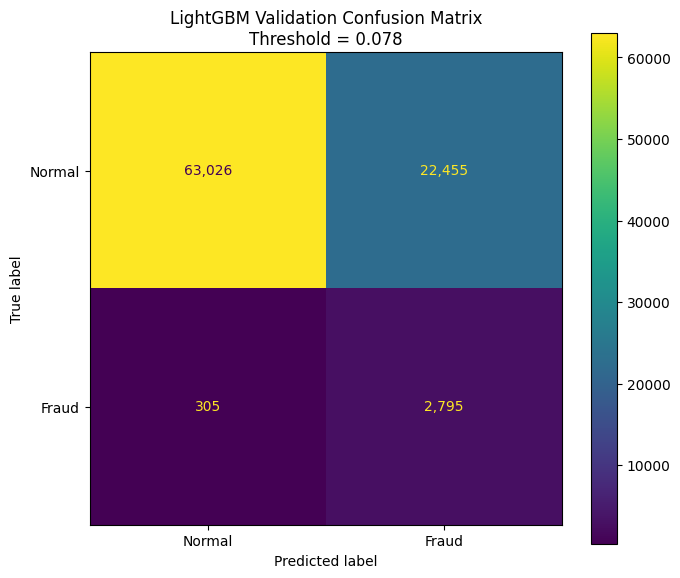

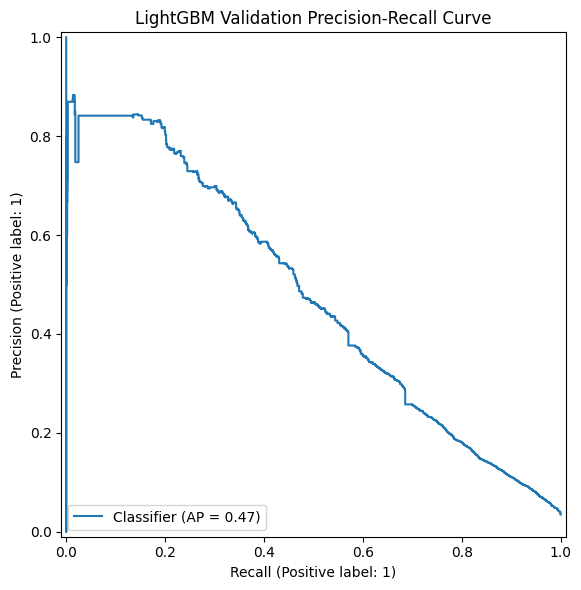

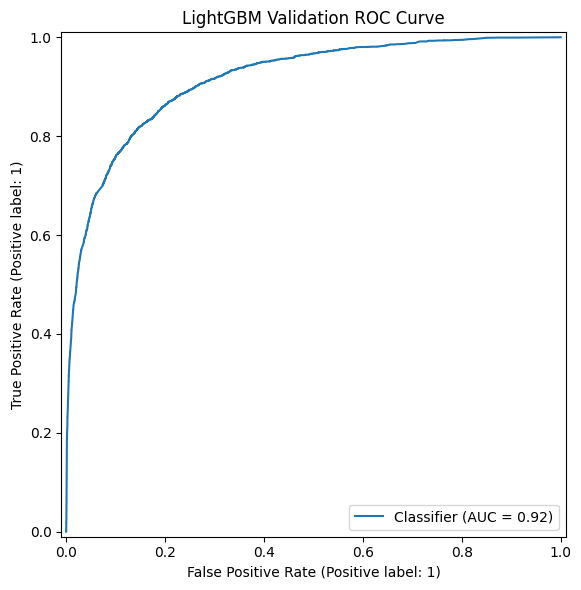

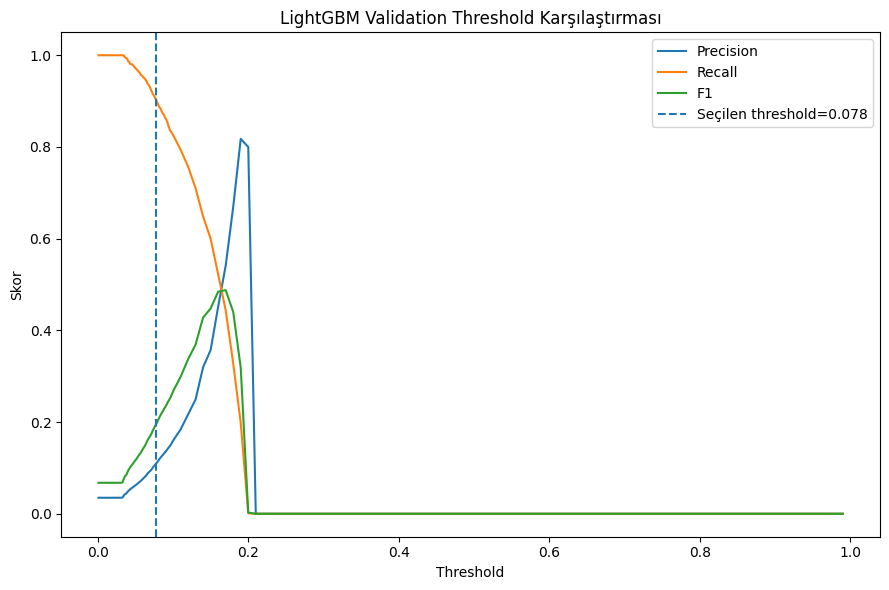

In [ ]:
# ============================================================
# 22) VALIDATION GÖRSELLERİ
# ============================================================

validation_predictions = (
    validation_probabilities >= selected_threshold
).astype(np.int8)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    validation_predictions,
    labels=[0, 1],
    display_labels=["Normal", "Fraud"],
    values_format=",d",
    ax=ax,
)
ax.set_title(
    f"LightGBM Validation Confusion Matrix\n"
    f"Threshold = {selected_threshold:.3f}"
)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "lightgbm_validation_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(
    y_val,
    validation_probabilities,
    ax=ax,
)
ax.set_title("LightGBM Validation Precision-Recall Curve")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "lightgbm_validation_precision_recall_curve.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

# ROC Curve
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_val,
    validation_probabilities,
    ax=ax,
)
ax.set_title("LightGBM Validation ROC Curve")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "lightgbm_validation_roc_curve.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

# Threshold karşılaştırması
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision",
)
ax.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall",
)
ax.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1",
)
ax.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Seçilen threshold={selected_threshold:.3f}",
)
ax.set_xlabel("Threshold")
ax.set_ylabel("Skor")
ax.set_title("LightGBM Validation Threshold Karşılaştırması")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "lightgbm_threshold_comparison.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

## Final test değerlendirmesi

Validation üzerinde seçilen model ve threshold değiştirilmeden test setine uygulanır.

In [ ]:
# ============================================================
# 23) TEST SETİNDE FİNAL DEĞERLENDİRME
# ============================================================

with StepTimer("Test tahminleri"):
    test_started = time.perf_counter()
    test_probabilities = model.predict_proba(X_test)[:, 1]
    test_inference_seconds = time.perf_counter() - test_started

test_predictions = (
    test_probabilities >= selected_threshold
).astype(np.int8)

test_metrics = calculate_metrics(
    y_test,
    test_probabilities,
    threshold=selected_threshold,
)

test_metrics.update({
    "model": "LGBMClassifier",
    "model_role": "heavy",
    "device": used_device,
    "training_seconds": float(training_seconds),
    "test_inference_seconds": float(test_inference_seconds),
    "test_rows": int(len(y_test)),
    "inference_seconds_per_10k": float(
        test_inference_seconds / len(y_test) * 10_000
    ),
    "best_iteration": int(model.best_iteration_),
    "selection_reason": selection_reason,
    "scale_pos_weight": float(scale_pos_weight),
})

display(pd.Series(test_metrics, name="LightGBM Test"))

In [ ]:
# ============================================================
# 24) 10 BİN SATIRLIK INFERENCE SÜRESİNİ 5 KEZ ÖLÇ
# ============================================================

sample_size = min(10_000, len(X_test))
inference_sample = X_test.iloc[:sample_size]

inference_times = []

for repeat in range(5):
    started = time.perf_counter()
    _ = model.predict_proba(inference_sample)[:, 1]
    elapsed = time.perf_counter() - started

    normalized_to_10k = (
        elapsed / sample_size * 10_000
    )
    inference_times.append(normalized_to_10k)

print("10K inference tekrarları:", inference_times)
print("10K ortalama süre:", np.mean(inference_times), "sn")
print("10K standart sapma:", np.std(inference_times), "sn")

test_metrics["inference_seconds_10k_mean"] = float(
    np.mean(inference_times)
)
test_metrics["inference_seconds_10k_std"] = float(
    np.std(inference_times)
)

In [ ]:
# ============================================================
# 25) TEST GÖRSELLERİ
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=[0, 1],
    display_labels=["Normal", "Fraud"],
    values_format=",d",
    ax=ax,
)
ax.set_title(
    f"LightGBM Test Confusion Matrix\n"
    f"Threshold = {selected_threshold:.3f}"
)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "lightgbm_test_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=ax,
)
ax.set_title("LightGBM Test Precision-Recall Curve")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "lightgbm_test_precision_recall_curve.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=ax,
)
ax.set_title("LightGBM Test ROC Curve")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "lightgbm_test_roc_curve.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

## Feature importance

LightGBM'in gain tabanlı feature importance değeri kullanılır. Bu çıktı nedensellik göstermez; modelin karar verirken hangi feature'lardan daha fazla yararlandığına ilişkin bir sinyaldir.

In [ ]:
# ============================================================
# 26) FEATURE IMPORTANCE
# ============================================================

importance_values = model.booster_.feature_importance(
    importance_type="gain"
)

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance_gain": importance_values,
}).sort_values(
    "importance_gain",
    ascending=False,
).reset_index(drop=True)

importance_csv_path = (
    METRICS_DIR
    / "lightgbm_feature_importance.csv"
)
feature_importance.to_csv(
    importance_csv_path,
    index=False,
)

top_n = min(30, len(feature_importance))
top_importance = (
    feature_importance
    .head(top_n)
    .sort_values("importance_gain")
)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(
    top_importance["feature"],
    top_importance["importance_gain"],
)
ax.set_xlabel("Gain Importance")
ax.set_ylabel("Feature")
ax.set_title(f"LightGBM En Önemli {top_n} Feature")
fig.tight_layout()

importance_figure_path = (
    FIGURES_DIR
    / "lightgbm_feature_importance_top30.png"
)
fig.savefig(
    importance_figure_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

display(feature_importance.head(30))

## Model, metadata ve sonuçların kaydedilmesi

Kaydedilen bundle şunları içerir:

- Eğitilmiş LightGBM modeli
- Seçilen threshold
- Feature listesi
- Kategorik kolon listesi
- Train sırasında öğrenilen kategori seviyeleri
- Kaldırılan kolonlar
- Temel model parametreleri

In [ ]:
# ============================================================
# 27) MODELİ VE SONUÇLARI KAYDET
# ============================================================

# Native LightGBM model dosyası
native_model_path = (
    MODEL_DIR
    / "lightgbm_heavy_model.txt"
)
model.booster_.save_model(native_model_path)

# Python bundle
bundle = {
    "model": model,
    "threshold": selected_threshold,
    "feature_columns": feature_columns,
    "categorical_columns": categorical_cols,
    "numeric_columns": numeric_cols,
    "categorical_levels": categorical_levels,
    "dropped_high_missing_columns": high_missing_cols,
    "dropped_constant_columns": constant_cols,
    "target_column": TARGET_COL,
    "id_column": ID_COL,
    "base_model_params": base_model_params,
}

bundle_path = (
    MODEL_DIR
    / "lightgbm_heavy_model_bundle.joblib"
)
joblib.dump(bundle, bundle_path)

# Test metrikleri
metrics_path = (
    METRICS_DIR
    / "lightgbm_test_metrics.json"
)

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(
        test_metrics,
        file,
        ensure_ascii=False,
        indent=2,
    )

# Metadata
metadata = {
    "model_name": "lightgbm_heavy_model",
    "model_role": "heavy",
    "native_model_path": str(native_model_path),
    "bundle_path": str(bundle_path),
    "target_column": TARGET_COL,
    "id_column": ID_COL,
    "feature_count": len(feature_columns),
    "feature_columns": feature_columns,
    "categorical_columns": categorical_cols,
    "numeric_columns": numeric_cols,
    "high_missing_threshold": HIGH_MISSING_THRESHOLD,
    "dropped_high_missing_columns": high_missing_cols,
    "dropped_constant_columns": constant_cols,
    "selected_threshold": selected_threshold,
    "selection_reason": selection_reason,
    "device": used_device,
    "best_iteration": int(model.best_iteration_),
    "scale_pos_weight": float(scale_pos_weight),
    "base_model_params": base_model_params,
    "test_metrics": test_metrics,
}

metadata_path = (
    MODEL_DIR
    / "lightgbm_heavy_model_metadata.json"
)

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

# Test tahminleri
test_predictions_frame = pd.DataFrame({
    "TransactionID": id_test,
    "y_true": y_test,
    "fraud_probability": test_probabilities,
    "prediction": test_predictions,
})

predictions_path = (
    PREDICTIONS_DIR
    / "lightgbm_test_predictions.csv"
)
test_predictions_frame.to_csv(
    predictions_path,
    index=False,
)

print("Native model:", native_model_path)
print("Model bundle:", bundle_path)
print("Metadata:", metadata_path)
print("Test metrikleri:", metrics_path)
print("Test tahminleri:", predictions_path)
print("Threshold tablosu:", threshold_path)
print("Feature importance:", importance_csv_path)

In [ ]:
# ============================================================
# 28) TAMAMLANMA ÖZETİ
# ============================================================

summary = pd.DataFrame([
    {
        "Model": "LightGBM",
        "Rol": "Ağır model adayı",
        "Cihaz": used_device,
        "Threshold": selected_threshold,
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1": test_metrics["f1"],
        "ROC-AUC": test_metrics["roc_auc"],
        "PR-AUC": test_metrics["pr_auc"],
        "Training dakika": training_seconds / 60,
        "10K inference sn": test_metrics[
            "inference_seconds_10k_mean"
        ],
    }
])

display(summary)

print("\nLIGHTGBM HEAVY MODEL NOTEBOOK'U TAMAMLANDI.")
print(
    "Sonraki adım: LightGBM sonucunu CatBoost ve diğer ağır "
    "model adaylarıyla aynı split üzerinde karşılaştırmak."
)

# Beklenen çıktılar

Notebook tamamlandığında Drive içindeki proje klasöründe yaklaşık olarak şu dosyalar oluşur:

```text
models/heavy/
├── lightgbm_heavy_model.txt
├── lightgbm_heavy_model_bundle.joblib
└── lightgbm_heavy_model_metadata.json

outputs/metrics/
├── lightgbm_data_report.json
├── lightgbm_split_indices.npz
├── lightgbm_validation_threshold_results.csv
├── lightgbm_test_metrics.json
└── lightgbm_feature_importance.csv

outputs/predictions/
└── lightgbm_test_predictions.csv

outputs/figures/
├── lightgbm_validation_confusion_matrix.png
├── lightgbm_validation_precision_recall_curve.png
├── lightgbm_validation_roc_curve.png
├── lightgbm_threshold_comparison.png
├── lightgbm_test_confusion_matrix.png
├── lightgbm_test_precision_recall_curve.png
├── lightgbm_test_roc_curve.png
└── lightgbm_feature_importance_top30.png
```

## Not

Bu notebook LightGBM'i **ağır model adayı** olarak hazırlar. Kesin model seçimi, aynı split üzerinde CatBoost ve diğer ağır model sonuçlarıyla karşılaştırma yapıldıktan sonra verilmelidir.